# 07 — Máscaras, CMAP e avaliação de trajetórias (`masking`, `transitions`, `cmap`, `trajectory_assessment`)

Origem: `cloud_masking.R`, `CMAP_FUNCTIONS.ipynb` e `trajectory_assessment.R`.

<details><summary><b>Correções e diferenças em relação aos originais</b></summary>

| Ponto | Original | Python |
|---|---|---|
| Chamadas de exemplo em `trajectory_assessment.R` | função com 4 argumentos (`prefixo` foi incluído depois), exemplos com 3 → erro | caminhos explícitos |
| Codificação das trajetórias | $\sum 10^{6-i}\,c_i$: no máximo **6 datas** e classes de **um dígito** | avaliação transição a transição (impossível se algum $M_t[c_t, c_{t+1}] = 0$, equivalente a $P(s)=0$), sem limites |
| 1 matriz de transição | `pesoFinal` só era criado com > 1 matriz → nenhuma trajetória marcada | funciona com qualquer nº |
| Totais da comparação | `rownames(tabela) > 0` comparava **texto** | comparação numérica (no Linux o resultado coincidiu; no Windows não pude testar) |
| Códigos MaxVer × CMAP | comparados diretamente; o CMAP Python codifica em ordem alfabética | `class_codes` comum e legendas: a comparação é feita pelo nome da classe |
| NA na máscara de nuvens | erro em `masking_replace` | ignorado |
| Formatos de matriz | numérica sem rótulos (avaliação) × com rótulos (CMAP) | `read_transition_matrix(..., has_labels=True/False)` lê os dois |

**Equivalência verificada:**
- Com o R: % de trajetórias impossíveis e raster pixel a pixel; % de discordância por data e total, e raster acumulado; máscara.
- Com o `CMAP_FUNCTIONS.ipynb` validado: tabela de P(s), `Trajectory_IDs` e mapas por data.
</details>

In [1]:
import sys, tempfile
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))   # pasta que contém sar_classification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_origin
from sar_classification import (sampling, autocorrelation as ac, masking, transitions as trn, cmap,
                                trajectory_assessment as ta, models as mdl, raster_io as rio,
                                validation as val, fitting as fit, separability as sep, plots)

In [2]:
# ---------------------------------------------------------------------------------
# Cena fictícia: 4 classes em blocos, série de 3 datas (intensidade HH, Gama L = 4),
# textura espacial (speckle correlado), mudança de uma região entre as datas,
# raster de amostras (polígonos rasterizados) e máscara de nuvens.
# ---------------------------------------------------------------------------------
from scipy.ndimage import gaussian_filter
from shapely.geometry import box
import geopandas as gpd

rng = np.random.default_rng(2024)
WORK = Path(tempfile.mkdtemp())
H, W, RES = 120, 160, 12.5
TR = from_origin(300000, 7400000, RES, RES)
CRS = 'EPSG:31983'
classes = ['F', 'VS', 'PA', 'SE']
mu = {'F': 0.08, 'VS': 0.055, 'PA': 0.025, 'SE': 0.012}

truth0 = np.repeat(np.arange(4), W // 4)[None, :].repeat(H, axis=0)
truths = [truth0.copy(), truth0.copy(), truth0.copy()]
truths[1][:40, 40:80] = 2                       # VS -> PA (desmatamento) a partir da data 2
truths[2][:40, 40:80] = 2

def write(path, arr, dtype, nodata=None, desc=None):
    arr = arr if arr.ndim == 3 else arr[None]
    with rasterio.open(path, 'w', driver='GTiff', height=H, width=W, count=arr.shape[0], dtype=dtype,
                       crs=CRS, transform=TR, nodata=nodata) as dst:
        dst.write(arr.astype(dtype))
        for i, n in enumerate(desc or []):
            dst.set_band_description(i + 1, n)
    return path

images = []
for t, truth in enumerate(truths):
    tex = gaussian_filter(rng.normal(size=(H, W)), 2.0); tex = np.exp(0.6 * tex / tex.std())
    mean = np.array([mu[c] for c in classes])[truth] * tex
    images.append(write(WORK / f'HH_{2005 + t}.tif', rng.gamma(4.0, mean / 4.0), 'float32', desc=['HH']))

cloud = np.zeros((H, W), np.uint8); cloud[90:110, 100:140] = 1
write(WORK / 'nuvens.tif', cloud, 'uint8')

# polígonos de amostra (retângulos) e raster de amostras (códigos 1..4; 0 = fundo)
polys, labels, sample_r = [], [], np.zeros((H, W), np.int16)
for k, c in enumerate(classes):
    for _ in range(6):
        r0, c0 = rng.integers(45, H - 22), rng.integers(k * 40 + 1, k * 40 + 19)
        sample_r[r0:r0 + 20, c0:c0 + 20] = k + 1
        x0, y0 = TR * (c0, r0 + 20); x1, y1 = TR * (c0 + 20, r0)
        polys.append(box(x0, y0, x1, y1)); labels.append(c)
write(WORK / 'amostras_2005.tif', sample_r, 'int16', nodata=0)
polygons = gpd.GeoDataFrame({'Classe': labels}, geometry=polys, crs=CRS)
print('Arquivos fictícios em', WORK)

Arquivos fictícios em /tmp/tmp_vblb78y


## 1. Máscara de nuvens

| Função | Descrição |
|---|---|
| `mask_array(image, mask, value, mask_value=1)` | substitui, em todas as bandas, os pixels com `mask == mask_value` |
| `apply_mask(image_path, mask_path, output_path, value, mask_value=1, set_as_nodata=True)` | versão em arquivo; confere dimensões, CRS e grade; `value` passa a ser o nodata da saída |

In [3]:
masked = [masking.apply_mask(p, WORK / 'nuvens.tif', str(p).replace('.tif', '_mask.tif'), value=np.nan) for p in images]

800 pixels mascarados em 1 banda(s) -> /tmp/tmp_vblb78y/HH_2005_mask.tif
800 pixels mascarados em 1 banda(s) -> /tmp/tmp_vblb78y/HH_2006_mask.tif
800 pixels mascarados em 1 banda(s) -> /tmp/tmp_vblb78y/HH_2007_mask.tif


## 2. Matrizes de transição — `transitions`

| Função | Descrição |
|---|---|
| `read_transition_matrix(path, sep=';', has_labels=True, class_names=None)` | com rótulos (CMAP) ou numérica (`has_labels=False`; classes `'1'..'K'` ou `class_names`) |
| `trajectory_priors(matrices, initial_probs=None)` | todas as trajetórias e $P(s)$ (Eq. 2.12) |
| `create_transition_matrix_table(file_paths, output_path=None, ...)` | leitura + $P(s)$ (+ CSV) |

Na matriz de validade (abordagem simplificada), as linhas não somam 1. Nesse caso, a leitura emite um aviso, que é esperado.

In [4]:
valid = pd.DataFrame(np.eye(4), index=classes, columns=classes); valid.loc['VS', 'PA'] = 1
for name in ('2005-2006', '2006-2007'):
    valid.to_csv(WORK / f'{name}.txt', sep=';')
mat_files = [WORK / '2005-2006.txt', WORK / '2006-2007.txt']
trajectories = trn.create_transition_matrix_table(mat_files)
trajectories[trajectories.final_weight > 0]

Aviso: em '2005-2006.txt', 1 linha(s) não somam 1 (Eq. 2.13) — esperado apenas em matriz de validade.
Aviso: em '2006-2007.txt', 1 linha(s) não somam 1 (Eq. 2.13) — esperado apenas em matriz de validade.
Trajetórias: 64 | P(s) > 0: 6 | inválidas: 58 | P(ω1) uniforme


,Stage_1,Stage_2,Stage_3,weight_1,weight_2,final_weight
0,F,F,F,1.0,1.0,1.0
21,VS,VS,VS,1.0,1.0,1.0
22,VS,VS,PA,1.0,1.0,1.0
26,VS,PA,PA,1.0,1.0,1.0
42,PA,PA,PA,1.0,1.0,1.0
63,SE,SE,SE,1.0,1.0,1.0


## 3. CMAP — `cmap_classifier(tif_paths, weights_df, bands_config=None, output_dir, date_labels, class_codes=None, input_is_log=False)`

$$\hat{s} = \arg\max_s\ \log P(s) + \sum_t \log P(\vec{o}_t \mid \omega_t)$$

| Parâmetro | Descrição |
|---|---|
| `bands_config` | `None` lê as classes da descrição das bandas (gravada por `likelihood_raster`) |

Antes do CMAP, `raster_io.verify_rasters(paths, bands_config=None)` confere dimensões, CRS, alinhamento e nº de bandas.
| `class_codes` | `{classe: código}` de saída; use o **mesmo** de `classification_raster` para comparar com o MaxVer |
| `input_is_log` | `True` para rasters de `likelihood_raster(..., log=True)`, que são imunes a *underflow* |

As saídas são as mesmas do notebook CMAP: `Classified_<data>.tif`, `Trajectory_IDs.tif`, `Log_Posterior.tif`, `legend_keys.csv`, `trajectory_keys.csv` e `class_counts.csv`.

In [5]:
from sar_classification import sampling, fitting as fit
codes = cmap.default_class_codes(classes)
pts = sampling.raster_samples_to_points(WORK / 'amostras_2005.tif', classes)
lik_paths, ml_paths = [], []
for t, p in enumerate(masked):
    df = sampling.extract_samples(pts, p)
    model = mdl.fit_model(df, classes, 'gamma', ENL=4)
    lik_paths.append(rio.likelihood_raster(p, model, WORK / f'lik_{t}.tif', log=True))
    ml_paths.append(rio.classification_raster(p, model, WORK / f'MaxVer_{t}.tif', class_codes=codes)['raster'])

print('Rasters de verossimilhança compatíveis?')
assert rio.verify_rasters(lik_paths)

out = cmap.cmap_classifier(lik_paths, trajectories, output_dir=WORK / 'cmap', date_labels=['2005', '2006', '2007'],
                           class_codes=codes, input_is_log=True)

extract_samples: 667 pontos sem valor válido na imagem foram descartados.


extract_samples: 667 pontos sem valor válido na imagem foram descartados.


extract_samples: 667 pontos sem valor válido na imagem foram descartados.
Rasters de verossimilhança compatíveis?
  arquivo  linhas  colunas  bandas   dtype  nodata        crs      descricoes
lik_0.tif     120      160       4 float32     NaN EPSG:31983 [F, VS, PA, SE]
lik_1.tif     120      160       4 float32     NaN EPSG:31983 [F, VS, PA, SE]
lik_2.tif     120      160       4 float32     NaN EPSG:31983 [F, VS, PA, SE]
Sucesso: 3 rasters compatíveis (120 linhas x 160 colunas).
  Progresso:  16.7% (1/6)
  Progresso:  33.3% (2/6)
  Progresso:  50.0% (3/6)
  Progresso:  66.7% (4/6)
  Progresso:  83.3% (5/6)
  Progresso: 100.0% (6/6)
Pixels válidos: 18400 de 19200 | classificados: 18400
Saídas em: /tmp/tmp_vblb78y/cmap


### Visualização

| Função | Descrição |
|---|---|
| `plots.plot_classification_results(paths, titles, legend_path)` | mapas lado a lado, mesma cor para a mesma classe em todas as datas |
| `plots.plot_single_raster(path, band=1, title, cmap)` | banda contínua (ex.: `Log_Posterior.tif`) |

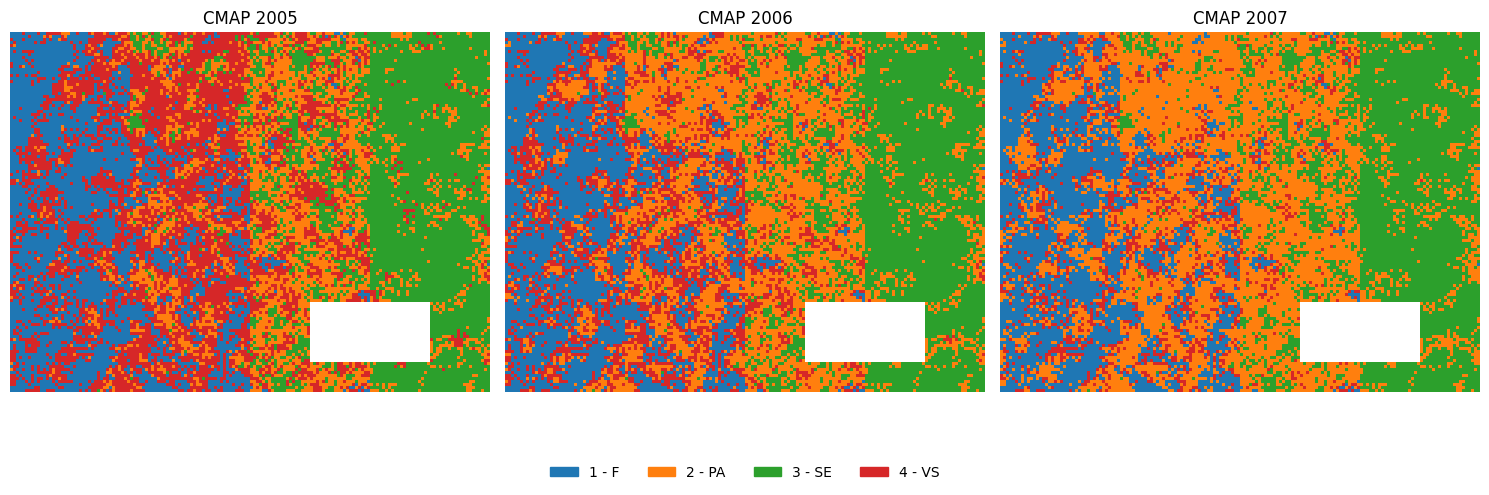

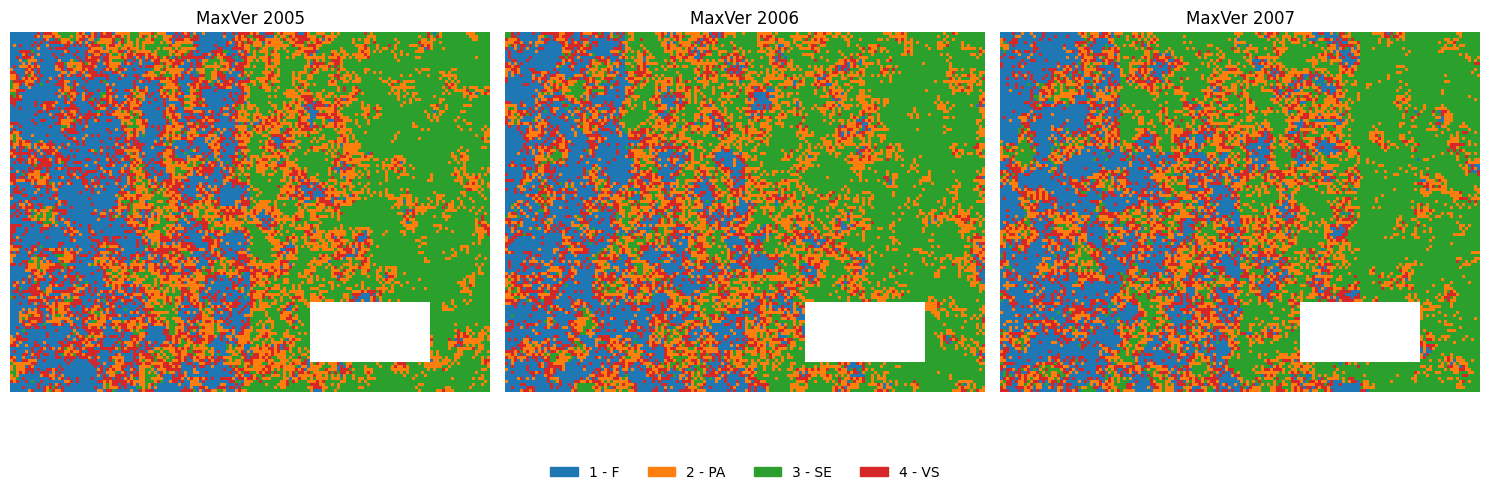

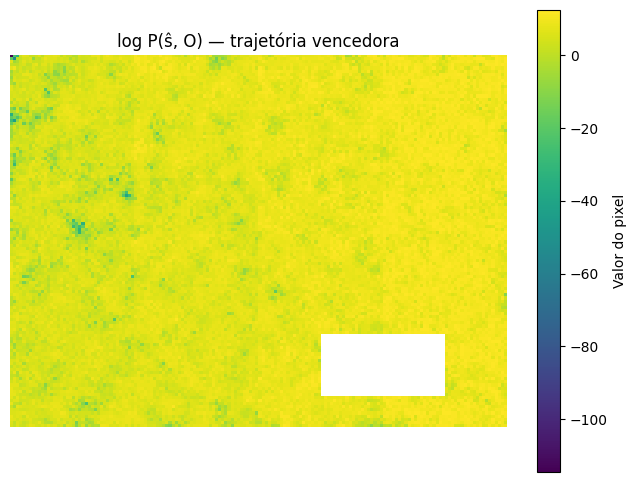

In [6]:
plots.plot_classification_results(out['classified'], ['CMAP 2005', 'CMAP 2006', 'CMAP 2007'], out['legend'])
plots.plot_classification_results(ml_paths, ['MaxVer 2005', 'MaxVer 2006', 'MaxVer 2007'], out['legend'])
plots.plot_single_raster(out['log_posterior'], title='log P(ŝ, O) — trajetória vencedora')

## 4. Trajetórias impossíveis — `impossible_trajectories(classified_paths, matrices, legends=None, mask_path=None, output_path=None, exclude_codes=None)`

Calcula a porcentagem de pixels cuja sequência de classes, por exemplo a do MaxVer empilhado, é impossível segundo as matrizes. Um pixel é válido se tem classe em todas as datas e está fora da máscara.

| Parâmetro | Descrição |
|---|---|
| `legends` | `{código: classe}`, uma para todas as datas ou uma por data; `None` usa o próprio código como nome, compatível com matrizes numéricas |
| `exclude_codes` | códigos tratados como nodata (ex.: `[0]`) |

Retorna `percentage`, `n_valid`, `n_impossible`, `n_unknown` e `table`, com as trajetórias impossíveis mais frequentes. Também grava um raster quando `output_path` é informado (1 = impossível, 255 = inválido).

In [7]:
legend = {v: k for k, v in codes.items()}
mats = [trn.read_transition_matrix(p, verbose=False) for p in mat_files]
imp = ta.impossible_trajectories(ml_paths, mats, legends=legend, output_path=WORK / 'impossiveis_maxver.tif')
print(f"MaxVer: {imp['percentage']:.2f}% de trajetórias impossíveis ({imp['n_impossible']} de {imp['n_valid']} pixels)")
print(f"CMAP:   {ta.impossible_trajectories(out['classified'], mats, legends=legend)['percentage']:.2f}% (por construção, 0)")
imp['table']

MaxVer: 76.71% de trajetórias impossíveis (14114 de 18400 pixels)
CMAP:   0.00% (por construção, 0)


,Stage_1,Stage_2,Stage_3,n_pixels
0,SE,PA,SE,940
1,PA,SE,SE,897
2,SE,SE,PA,712
3,PA,PA,SE,564
4,PA,SE,PA,435
5,VS,F,F,423
6,F,VS,F,363
7,SE,PA,PA,358
8,PA,F,F,347
9,F,F,VS,342


## 5. MaxVer × CMAP — `compare_classifications(paths_a, paths_b, mask_path=None, legend_a=None, legend_b=None, date_labels=None, output_path=None)`

- **Por data:** porcentagem de pixels com classes diferentes, entre os válidos nas duas séries e fora da máscara.
- **Acumulado:** número de datas com discordância por pixel (−1 = máscara, −9999 = inválido).
- **Total:** porcentagem de pixels com ao menos uma discordância.

Sem legendas, os **códigos** são comparados diretamente, e a função avisa.

In [8]:
cmp = ta.compare_classifications(ml_paths, out['classified'], WORK / 'nuvens.tif', legend, legend,
                                 date_labels=['2005', '2006', '2007'], output_path=WORK / 'discordancia.tif')
cmp['histogram']

date  n_valid  n_disagree  percentage
2005    18400        7349      39.940
2006    18400        7492      40.717
2007    18400        7602      41.315
Discordância total (>= 1 data): 76.707%


n_disagreements
0    4286
1    7556
2    4787
3    1771
Name: n_pixels, dtype: int64